# TweetEval sentiment
https://huggingface.co/datasets/cardiffnlp/tweet_eval

In [13]:
from datasets import load_dataset

ds = load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(ds)

README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [14]:
for i in range(5):
    print(ds["train"][i])

{'text': '"QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"', 'label': 2}
{'text': '"Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"', 'label': 1}
{'text': 'Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.', 'label': 1}
{'text': "Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays", 'label': 1}
{'text': '@user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"', 'label': 2}


In [15]:
for i in range(5):
    print(f"Text: {ds['train'][i]['text']}")
    print(f"Label: {ds['train'][i]['label']}")
    print("-" * 50)

Text: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Label: 2
--------------------------------------------------
Text: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Label: 1
--------------------------------------------------
Text: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
Label: 1
--------------------------------------------------
Text: Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
Label: 1
--------------------------------------------------
Text: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"
Label: 2
--------------------------------------------------


# Create a small hand-labeled in-domain validation set from our own election tweets

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import numpy as np
import pandas as pd

path = "/content/hashtag_donaldtrump.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/hashtag_donaldtrump.csv'

In [ ]:
n_sample = 300
small_sample = dt.sample(n=min(n_sample, len(dt)), random_state=42).copy()

In [ ]:
# small_sample.to_csv("small_sample.csv", index = False)

# Apply cardiffnlp model
https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment

In [ ]:
!pip -q install transformers scipy scikit-learn

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [ ]:
path = "/content/small_sample_v3.csv"

dt = pd.read_csv(
    path,
    engine="python",
    on_bad_lines="warn"
)

print(dt.shape)
print(dt.columns.tolist())
dt.head(20)

## Preprocess text


### remove short and non-english tweets

In [ ]:
!pip install lingua-language-detector

In [ ]:
from lingua import Language, LanguageDetectorBuilder
detector = LanguageDetectorBuilder.from_all_languages().build()

In [ ]:
def remove_short_and_non_english(text):
    # Return None for very short tweets — lingua is unreliable under ~5 words
    if len(str(text).split()) < 5:
        return None

    detected = detector.detect_language_of(str(text))
    return detected == Language.ENGLISH

In [ ]:
dt['is_english'] = dt['tweet'].apply(remove_short_and_non_english)

In [ ]:
print(dt['is_english'].value_counts(dropna=False))

In [ ]:
dt_english = dt[dt['is_english'] == True].copy()

### remove urls

In [ ]:
import re

def remove_urls(text):
    pattern = r'https?://\S+|www\.\S+'
    return re.sub(pattern, '', text).strip()

In [ ]:
dt_english['tweet_clean'] = dt_english['tweet'].apply(remove_urls)

In [ ]:
dt_english = dt_english[dt_english['tweet_clean'].str.strip() != ''].copy()
dt_english = dt_english.reset_index(drop=True)

In [ ]:
dt_english

### modeling on dt_english

In [ ]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [ ]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [ ]:
# PreTrain
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.save_pretrained(MODEL)

In [ ]:
import torch
def predict_sentiment_dict(text):
  encoded_input = tokenizer(
        text,
        return_tensors="pt"
    )

  with torch.no_grad():
        output = model(**encoded_input)

  scores = output.logits[0].detach().numpy()
  probs = softmax(scores)

  prob_dict = {
        labels[i]: float(probs[i]) for i in range(len(labels))
    }

  return prob_dict

In [ ]:
dt_english["sentiment_probs"] = dt_english["tweet"].apply(predict_sentiment_dict)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs"]].head()

In [ ]:
def get_top_label(prob_dict):
    return max(prob_dict, key=prob_dict.get)

dt_english["sentiment_label"] = dt_english["sentiment_probs"].apply(get_top_label)

In [ ]:
label_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

dt_english["sentiment_label_id"] = dt_english["sentiment_label"].map(label_to_id)

In [ ]:
dt_english[["tweet", 'human_label_context', 'human_label_words_only', "sentiment_probs", 'sentiment_label', 'sentiment_label_id']].head()

In [ ]:
# dt_english.to_csv("dt_english_predicted.csv", index = False)

### Confusion matrix

In [ ]:
dt_english['human_label_context'] = dt_english['human_label_context'].astype(int)
dt_english['sentiment_label_id'] = dt_english['sentiment_label_id'].astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Context')
plt.title('RoBERTa vs Human Labels Context')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_context'],
    dt_english['sentiment_label_id']
))

In [ ]:
print(classification_report(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0],
    target_names=['positive', 'neutral', 'negative']
))

cm = confusion_matrix(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id'],
    labels=[2, 1, 0]
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['positive', 'neutral', 'negative'],
    yticklabels=['positive', 'neutral', 'negative']
)

plt.xlabel('RoBERTa Predicted')
plt.ylabel('Human Label Words')
plt.title('RoBERTa vs Human Labels Words')
plt.show()

print("Cohen's kappa:", cohen_kappa_score(
    dt_english['human_label_words_only'],
    dt_english['sentiment_label_id']
))

# Combining both sheets into one CSV

In [ ]:
biden = pd.read_csv("/content/hashtag_joebiden.csv")

In [ ]:
trump = pd.read_csv("/content/hashtag_donaldtrump.csv", engine="python")

In [ ]:
merged = pd.concat([biden, trump], ignore_index=True)

# Remove duplicates based on a specific column, keeping the first occurrence
merged = merged.drop_duplicates(subset=["tweet_id"], keep="first")

merged = merged.reset_index(drop=True)

In [ ]:
merged['likes'].dtype

In [ ]:
# filter zero likes
merged['likes'] = pd.to_numeric(merged['likes'], errors='coerce')
merged = merged[merged['likes'] != 0]

In [ ]:
merged = merged.reset_index(drop=True)
merged

In [ ]:
merged = merged.dropna(subset=['likes'])

In [ ]:
len(merged)

In [ ]:
# Save result
# merged.to_csv("merged_output.csv", index=False)

# Calculate engagement score

In [ ]:
import numpy as np

In [ ]:
merged_english = pd.read_csv("merged_english.csv")

In [ ]:
merged_english["user_followers_count"] = pd.to_numeric(merged_english["user_followers_count"], errors='coerce')

In [ ]:
merged_english['E_raw'] = (merged_english['likes'] + 2 * merged_english['retweet_count']) / (merged_english['user_followers_count'] + 1)
merged_english['E_log'] = np.log1p(merged_english['E_raw'])
log_min = merged_english['E_log'].min()
log_max = merged_english['E_log'].max()
merged_english['E_score'] = (merged_english['E_log'] - log_min) / (log_max - log_min)

In [ ]:
merged_english.head()

In [ ]:
merged_english["country"].unique()

In [ ]:
((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")).sum()

In [ ]:
df = merged_english[((merged_english["country"] == "United States") | (merged_english["country"] == "United States of America")) & (merged_english["state"].notna())]

In [ ]:
len(df)

# Sentiment Analysis

In [22]:
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import numpy as np
from scipy.special import softmax
import csv
import urllib.request

In [23]:
task='sentiment'
MODEL = f"cardiffnlp/twitter-roberta-base-{task}"

In [24]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [25]:
# download label mapping
labels=[]
mapping_link = f"https://raw.githubusercontent.com/cardiffnlp/tweeteval/main/datasets/{task}/mapping.txt"
with urllib.request.urlopen(mapping_link) as f:
    html = f.read().decode('utf-8').split("\n")
    csvreader = csv.reader(html, delimiter='\t')
labels = [row[1] for row in csvreader if len(row) > 1]

In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL).to(device)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [27]:
from torch.utils.data import DataLoader

tweets = df["tweet"].astype(str).tolist()

# Tokenize everything at once (returns tensors)
# padding=True and truncation=True make sure all tensors are the same shape
inputs = tokenizer(tweets, padding=True, truncation=True, return_tensors="pt", max_length=128)

# Create a DataLoader to feed the GPU in chunks
dataset = torch.utils.data.TensorDataset(inputs['input_ids'], inputs['attention_mask'])
loader = DataLoader(dataset, batch_size=32)

# Predict in a loop
model.eval()
model.to(device)
all_logits = []

with torch.no_grad():
    for batch in loader:
        b_input_ids, b_attn_mask = [t.to(device) for t in batch]
        outputs = model(input_ids=b_input_ids, attention_mask=b_attn_mask)
        all_logits.append(outputs.logits.cpu())

# Concatenate results and get labels
final_logits = torch.cat(all_logits, dim=0)
probs = torch.nn.functional.softmax(final_logits, dim=-1)

# Convert the probabilities tensor to a NumPy array
probs_np = probs.numpy()

# Add the raw probabilities to dataframe
df["sentiment_probs"] = probs_np.tolist()

# map to labels (labels obtained from the model itself)
indices = np.argmax(probs_np, axis=1)
df["sentiment_label"] = [labels[i] for i in indices]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
df.to_csv("df.csv", index=False)

In [ ]:
df = pd.read_csv("/content/df.csv")

# Importing df.csv

In [71]:
import pandas as pd

In [72]:
df = pd.read_csv("/content/df.csv")

In [73]:
print(len(df))

92213


In [74]:
print(df['state'].value_counts())

state
California              15952
New York                12694
Texas                    8308
Florida                  7540
District of Columbia     5002
Illinois                 3603
Pennsylvania             3512
New Jersey               2492
Massachusetts            2305
Ohio                     1972
Oregon                   1809
North Carolina           1749
Michigan                 1722
Arizona                  1681
Georgia                  1656
Colorado                 1603
Virginia                 1412
Nevada                   1398
Washington               1266
Maryland                 1172
Tennessee                1121
Minnesota                1025
Missouri                  922
Wisconsin                 828
Kentucky                  773
South Carolina            699
Indiana                   677
Louisiana                 666
Kansas                    573
Alabama                   513
Connecticut               510
Oklahoma                  485
Iowa                      458
Hawa

In [75]:
df = df[(df['state'] != "Guam") & (df['state'] != "Northern Mariana Islands")]
print(df['state'].value_counts())

state
California              15952
New York                12694
Texas                    8308
Florida                  7540
District of Columbia     5002
Illinois                 3603
Pennsylvania             3512
New Jersey               2492
Massachusetts            2305
Ohio                     1972
Oregon                   1809
North Carolina           1749
Michigan                 1722
Arizona                  1681
Georgia                  1656
Colorado                 1603
Virginia                 1412
Nevada                   1398
Washington               1266
Maryland                 1172
Tennessee                1121
Minnesota                1025
Missouri                  922
Wisconsin                 828
Kentucky                  773
South Carolina            699
Indiana                   677
Louisiana                 666
Kansas                    573
Alabama                   513
Connecticut               510
Oklahoma                  485
Iowa                      458
Hawa

In [76]:
df.columns

Index(['created_at', 'tweet_id', 'tweet', 'likes', 'retweet_count', 'source',
       'user_id', 'user_name', 'user_screen_name', 'user_description',
       'user_join_date', 'user_followers_count', 'user_location', 'lat',
       'long', 'city', 'country', 'continent', 'state', 'state_code',
       'collected_at', 'is_english', 'tweet_clean', 'E_raw', 'E_log',
       'E_score', 'sentiment_probs', 'sentiment_label'],
      dtype='object')

Final dataset:
- English only
- In the US
- State not NA

# Baseline models for comparison

## Baseline model 1:
- Input: user_id

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [7]:
df = df.dropna(subset=['user_followers_count']).copy()

In [8]:
df['log_followers_count'] = np.log1p(df['user_followers_count'])

In [9]:
y = df['E_score']
X = df[['log_followers_count']]

In [10]:
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]

In [11]:
# Compute mean engagement per user from training set only
user_mean_map = df_train.groupby('user_id')['E_score'].mean()
global_mean = y_train.mean()

# Map mean engagement onto each split
df_train['user_mean_engagement'] = df_train['user_id'].map(user_mean_map)
df_val['user_mean_engagement'] = df_val['user_id'].map(user_mean_map).fillna(global_mean)

# Train baseline
X_train_user = df_train[['user_mean_engagement']]
X_val_user = df_val[['user_mean_engagement']]

baseline_user = LinearRegression()
baseline_user.fit(X_train_user, y_train)

preds_user = baseline_user.predict(X_val_user)

print("User ID baseline:")
print(f"R²:   {r2_score(y_val, preds_user):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds_user):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds_user)):.4f}")

# Check how many unseen users got the global mean fallback
unseen = ~df_val['user_id'].isin(user_mean_map.index)
print(f"\nUnseen users in val: {unseen.sum()} ({unseen.mean():.1%})")

User ID baseline:
R²:   0.0148
MAE:  0.0038
RMSE: 0.0158

Unseen users in val: 3402 (37.1%)


## Baseline model 2:
- Input: follower count

In [12]:
# Single feature — reshape needed for sklearn
X_train_followers = X_train[['log_followers_count']]
X_val_followers = X_val[['log_followers_count']]

baseline_followers = LinearRegression()
baseline_followers.fit(X_train_followers, y_train)

preds = baseline_followers.predict(X_val_followers)

print("Follower count baseline:")
print(f"R²:   {r2_score(y_val, preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_val, preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, preds)):.4f}")

Follower count baseline:
R²:   0.1561
MAE:  0.0057
RMSE: 0.0146


With the baseline models showing **0.0766** and **0.1442** for their R^2 scores, this is what we need to beat in our model.

# Feature Engineering

In [77]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

tokenizer = AutoTokenizer.from_pretrained('Twitter/twhin-bert-base')
model = AutoModel.from_pretrained('Twitter/twhin-bert-base')
model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

def get_embeddings(texts, batch_size=64):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt',
                          truncation=True, max_length=128, padding=True)

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # Mean pooling — average over all non-padding tokens
        # Get the attention_mask that was set when we tokenized the input
        attention_mask = inputs['attention_mask']
        # Get the actual token embeddings that resulted from passing the input through the model
        token_embeddings = outputs.last_hidden_state

        # Expand mask to match embedding dimensions
        mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()

        # Sum embeddings where mask=1, divide by number of real tokens
        # By multiplying, we remove tokens part of the mask, then we sum all tokens to get one embedding per tweet
        sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
        # Sum the number of real (non-padding) tokens
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        mean_embeddings = sum_embeddings / sum_mask

        all_embeddings.append(mean_embeddings.cpu().numpy())

    return np.vstack(all_embeddings)

embeddings = get_embeddings(df['tweet_clean'].tolist())
np.save('twhin_embeddings.npy', embeddings)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Twitter/twhin-bert-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.distance_embedding.weight | UNEXPECTED | 
cls.predictions.bias                                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias                             | UNEXPECTED | 
cls.predictions.transform.dense.bias                                 | UNEXPECTED | 
bert.embeddings.position_ids                                         | UNEXPECTED | 
cls.predictions.transform.dense.weight                               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                           | UNEXPECTED | 
pooler.dense.weight                                                  | MISSING    | 
pooler.dense.bias                                                    | MISSING    | 

Notes:
- UNE

In [78]:
from datetime import datetime
df["created_at"] = pd.to_datetime(df["created_at"], format="%Y-%m-%d %H:%M:%S")
df["user_join_date"] = pd.to_datetime(df["user_join_date"], format="%Y-%m-%d %H:%M:%S")
df["account_age"] = (df["created_at"] - df["user_join_date"]).dt.days
df["log_account_age"] = np.log1p(df["account_age"])

election_date = pd.Timestamp("2020-11-03")
df["days_before_election"] = (election_date - df["created_at"]).dt.days
print(df["days_before_election"].describe())

count    92213.000000
mean         5.071226
std          7.331601
min         -6.000000
25%         -2.000000
50%          5.000000
75%         11.000000
max         18.000000
Name: days_before_election, dtype: float64


In [15]:
counts = df['source'].value_counts()

# Identify categories with less than 3000 occurrences
repl = counts[counts < 3000].index

# Replace those categories with "Others"
df['source'] = df['source'].replace(repl, 'Others')

In [16]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['E_score']

X = df.copy()

# First split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Then split remainder into train (80%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Now get the df splits
df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]
df_test = df.loc[X_test.index]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 36677, Val: 9170, Test: 11462


In [17]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['log_account_age', 'days_before_election']

scaler = StandardScaler()
continuous_train = scaler.fit_transform(df_train[continuous_cols])
continuous_val = scaler.transform(df_val[continuous_cols])
continuous_test = scaler.transform(df_test[continuous_cols])

In [18]:
from sklearn.preprocessing import OneHotEncoder

source_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
source_train = source_encoder.fit_transform(df_train[['source']])
source_val = source_encoder.transform(df_val[['source']])
source_test = source_encoder.transform(df_test[['source']])

In [19]:
sentiment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
sentiment_train = sentiment_encoder.fit_transform(df_train[['sentiment_label']])
sentiment_val = sentiment_encoder.transform(df_val[['sentiment_label']])
sentiment_test = sentiment_encoder.transform(df_test[['sentiment_label']])

In [20]:
# Create integer mapping
state_categories = df['state'].unique().tolist()
state_map = {state: idx for idx, state in enumerate(state_categories)}

state_train = df_train['state'].map(state_map).fillna(0).astype(int).values
state_val = df_val['state'].map(state_map).fillna(0).astype(int).values
state_test = df_test['state'].map(state_map).fillna(0).astype(int).values

num_states = len(state_map)

In [21]:
all_embeddings = np.load('twhin_embeddings.npy')
label_to_pos = {label: pos for pos, label in enumerate(df.index)}

train_positions = [label_to_pos[i] for i in df_train.index]
val_positions = [label_to_pos[i] for i in df_val.index]
test_positions = [label_to_pos[i] for i in df_test.index]

emb_train = all_embeddings[train_positions]
emb_val = all_embeddings[val_positions]
emb_test = all_embeddings[test_positions]

In [22]:
from torch.utils.data import Dataset, DataLoader

class TweetDataset(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                 sentiment_onehot, state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

In [23]:
train_dataset = TweetDataset(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset = TweetDataset(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset = TweetDataset(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [25]:
df["state"].unique()

array(['California', 'Illinois', 'Massachusetts', 'Virginia', 'New York',
       'Washington', 'Maryland', 'New Jersey', 'Montana',
       'South Carolina', 'Texas', 'Utah', 'Florida', 'North Carolina',
       'Pennsylvania', 'Arizona', 'Oregon', 'District of Columbia',
       'Oklahoma', 'New Mexico', 'Ohio', 'Kentucky', 'Nevada', 'Colorado',
       'Minnesota', 'Michigan', 'Idaho', 'Wisconsin', 'North Dakota',
       'Missouri', 'Georgia', 'Alabama', 'Arkansas', 'Tennessee', 'Maine',
       'Kansas', 'Hawaii', 'Indiana', 'Alaska', 'New Hampshire',
       'Louisiana', 'Mississippi', 'Iowa', 'Connecticut', 'West Virginia',
       'Puerto Rico', 'Rhode Island', 'Nebraska', 'Delaware', 'Vermont',
       'Wyoming', 'South Dakota'], dtype=object)

In [26]:
import torch
import torch.nn as nn

class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + \
                       sentiment_train.shape[1] + state_emb_dim
        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        # Build layers dynamically
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                sentiment_onehot, state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot,
            sentiment_onehot, state_emb
        ], dim=1)
        return self.network(combined).squeeze()

In [27]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.0 MB/s eta 0:00:00


In [28]:
import optuna
from optuna.trial import Trial
from sklearn.metrics import r2_score

def objective(trial):
    # Architecture, we are also adding the number of layers as a hyperparameter to be determined
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256, 512, 1024])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])

    # Optimizer
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)

    # Training
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])

    # Activation function
    activation = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    # Build model dynamically based on n_layers
    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        activation=activation,
        num_states=num_states
    ).to(device)

    # Select optimizer
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    # select loss, Huber is a mix between MSE and MAE
    loss_name = trial.suggest_categorical('loss', ['MSE', 'MAE', 'Huber'])

    if loss_name == 'MSE':
      criterion = nn.MSELoss()
    elif loss_name == 'MAE':
      criterion = nn.L1Loss()
    elif loss_name == 'Huber':
      criterion = nn.HuberLoss(delta=0.1)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_preds.extend(preds.cpu().numpy())

    # compare on R^2 score, not the different losses
    return r2_score(y_val.values, val_preds)

# Run the study
study = optuna.create_study(direction='maximize')  # maximize R²
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)
print(f"Best val R²: {study.best_value:.4f}")

[I 2026-05-14 00:12:54,425] A new study created in memory with name: no-name-258da740-f1d0-46ed-aeaa-261c48c834aa
[I 2026-05-14 00:13:32,792] Trial 0 finished with value: -0.04337320434474434 and parameters: {'n_layers': 3, 'hidden_dim_0': 64, 'hidden_dim_1': 1024, 'hidden_dim_2': 64, 'dropout': 0.4281685673967166, 'use_layernorm': True, 'optimizer': 'Adam', 'lr': 0.0005758124326964309, 'weight_decay': 0.00030578436448888674, 'batch_size': 32, 'activation': 'gelu', 'loss': 'MAE'}. Best is trial 0 with value: -0.04337320434474434.
[I 2026-05-14 00:14:01,645] Trial 1 finished with value: 0.10622845950379356 and parameters: {'n_layers': 2, 'hidden_dim_0': 512, 'hidden_dim_1': 64, 'dropout': 0.25043411064264315, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 4.1776523960845436e-05, 'weight_decay': 0.03601202399039368, 'batch_size': 32, 'activation': 'relu', 'loss': 'MSE'}. Best is trial 1 with value: 0.10622845950379356.
[I 2026-05-14 00:14:14,170] Trial 2 finished with value: -2.4266

Best hyperparameters:
{'n_layers': 3, 'hidden_dim_0': 512, 'hidden_dim_1': 512, 'hidden_dim_2': 128, 'dropout': 0.15193544854337981, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 7.307254154985156e-05, 'weight_decay': 0.008807997617545872, 'batch_size': 64, 'activation': 'leaky_relu', 'loss': 'MSE'}
Best val R²: 0.1351


In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

best_params = study.best_params

# Create dataloaders with best batch size
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

# Build final model with best hyperparameters
final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    activation=best_params['activation'],
    num_states=num_states
).to(device)

# Select best optimizer
if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

# Select best loss
if best_params['loss'] == 'MSE':
    criterion = nn.MSELoss()
elif best_params['loss'] == 'MAE':
    criterion = nn.L1Loss()
elif best_params['loss'] == 'Huber':
    criterion = nn.HuberLoss(delta=0.1)

# Track per epoch for plotting
train_losses_per_epoch = []
val_losses_per_epoch = []
val_r2_per_epoch = []

best_val_r2 = float('-inf')  # note: was float('inf') before which was a bug

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        preds = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(preds, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            preds = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_losses.append(criterion(preds, batch['target'].to(device)).item())
            val_preds.extend(preds.cpu().numpy())

    val_r2 = r2_score(y_val.values, val_preds)
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_r2_per_epoch.append(val_r2)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val R²: {val_r2:.4f}")

    # Save best model based on R²
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        torch.save(final_model.state_dict(), 'best_model.pt')
        print(f"  → New best model saved (R²={val_r2:.4f})")

print(f"\nTraining complete. Best val R²: {best_val_r2:.4f}")

  → New best model saved (R²=-0.1611)
  → New best model saved (R²=0.0039)
  → New best model saved (R²=0.0272)
Epoch 5/50 | Train Loss: 0.0003 | Val Loss: 0.0002 | Val R²: 0.0218
  → New best model saved (R²=0.1176)
Epoch 10/50 | Train Loss: 0.0002 | Val Loss: 0.0002 | Val R²: 0.0301
  → New best model saved (R²=0.1296)
Epoch 15/50 | Train Loss: 0.0002 | Val Loss: 0.0002 | Val R²: 0.1177
Epoch 20/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0675
Epoch 25/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0480
Epoch 30/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.1316
  → New best model saved (R²=0.1316)
Epoch 35/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0660
Epoch 40/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0232
Epoch 45/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0332
Epoch 50/50 | Train Loss: 0.0001 | Val Loss: 0.0002 | Val R²: 0.0559

Training complete. Best val R²: 0.1316


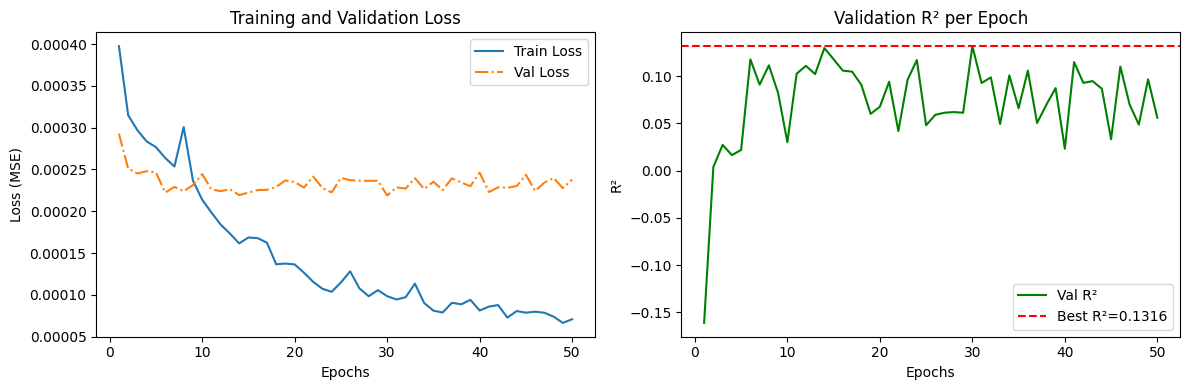

In [30]:
import matplotlib.pyplot as plt
epochs = range(1, 51)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(epochs, train_losses_per_epoch, label='Train Loss')
ax1.plot(epochs, val_losses_per_epoch, linestyle='-.', label='Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# R² plot
ax2.plot(epochs, val_r2_per_epoch, label='Val R²', color='green')
ax2.axhline(y=max(val_r2_per_epoch), color='red', linestyle='--',
            label=f'Best R²={max(val_r2_per_epoch):.4f}')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('R²')
ax2.set_title('Validation R² per Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [31]:
# Load best model
final_model.load_state_dict(torch.load('best_model.pt'))
final_model.eval()

test_dataset = TweetDataset(
    embeddings=all_embeddings[X_test.index],
    continuous_meta=scaler.transform(df_test[continuous_cols]),
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)
test_loader = DataLoader(test_dataset, batch_size=64)

test_preds = []
with torch.no_grad():
    for batch in test_loader:
        preds = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds.extend(preds.cpu().numpy())

print("Test Results:")
print(f"R²:   {r2_score(y_test, test_preds):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, test_preds):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, test_preds)):.4f}")

Test Results:
R²:   0.0578
MAE:  0.0042
RMSE: 0.0153


On the test set, we see that our model's R^2 is **0.0590**, worse than the 2 baselines models.

# Taking engagement as a categorical variable instead

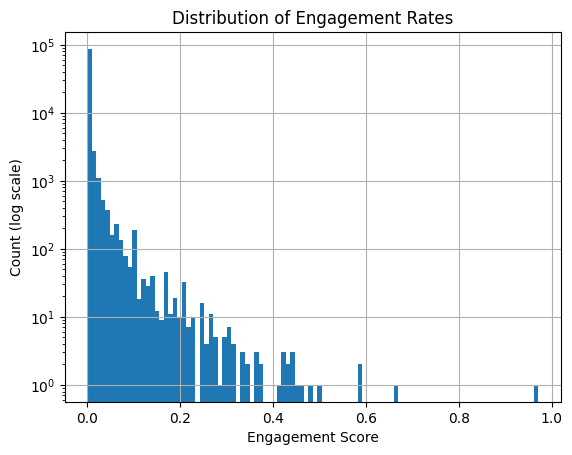

count    9.221300e+04
mean     3.448079e-03
std      1.614339e-02
min      1.105968e-07
25%      1.115728e-04
33%      1.667035e-04
50%      3.790608e-04
66%      8.369285e-04
75%      1.431940e-03
90%      5.534389e-03
95%      1.314504e-02
99%      6.125484e-02
max      9.704851e-01
Name: E_score, dtype: float64


In [79]:
import matplotlib.pyplot as plt

df['E_score'].hist(bins=100, log=True)
plt.xlabel('Engagement Score')
plt.ylabel('Count (log scale)')
plt.title('Distribution of Engagement Rates')
plt.show()

# Also look at percentiles to understand the distribution
print(df['E_score'].describe(percentiles=[.25, .33, .5, .66, .75, .90, .95, .99]))

In [80]:
df['engagement_label'] = pd.qcut(
    df['E_score'],
    q = 3,
    labels=[0, 1, 2]  # 0=low, 1=mid, 2=high
)

print(df['engagement_label'].value_counts().sort_index())
df['engagement_label'] = df['engagement_label'].astype(int)

engagement_label
0    30747
1    30751
2    30715
Name: count, dtype: int64


In [34]:
df = df.dropna(subset=['user_followers_count']).copy()
df['log_followers_count'] = np.log1p(df['user_followers_count'])

In [35]:
from sklearn.model_selection import train_test_split

# Target variable
y = df['engagement_label'].astype(int)

X = df.copy()

# First split off test set (20%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Then split remainder into train (80%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42
)

# Now get the df splits
df_train = df.loc[X_train.index]
df_val = df.loc[X_val.index]
df_test = df.loc[X_test.index]

print(f"Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")

Train: 36677, Val: 9170, Test: 11462


## Baseline models (same as in linear regression):

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

In [37]:
# Compute mean engagement per user from training set only
user_mean_map = df_train.groupby('user_id')['E_score'].mean()
global_mean = df_train['E_score'].mean()

df_train['user_mean_engagement'] = df_train['user_id'].map(user_mean_map)
df_val['user_mean_engagement'] = df_val['user_id'].map(user_mean_map).fillna(global_mean)

X_train_user = df_train[['user_mean_engagement']]
X_val_user = df_val[['user_mean_engagement']]

baseline_user = LogisticRegression(max_iter=1000)
baseline_user.fit(X_train_user, y_train)

preds_user = baseline_user.predict(X_val_user)

print("User ID baseline:")
print(classification_report(y_val, preds_user, target_names=['low', 'mid', 'high']))
print(f"Weighted F1: {f1_score(y_val, preds_user, average='weighted'):.4f}")

unseen = ~df_val['user_id'].isin(user_mean_map.index)
print(f"\nUnseen users in val: {unseen.sum()} ({unseen.mean():.1%})")

User ID baseline:
              precision    recall  f1-score   support

         low       0.45      0.76      0.56      3033
         mid       0.00      0.00      0.00      3056
        high       0.54      0.71      0.61      3081

    accuracy                           0.49      9170
   macro avg       0.33      0.49      0.39      9170
weighted avg       0.33      0.49      0.39      9170

Weighted F1: 0.3929

Unseen users in val: 3402 (37.1%)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Use the same log_followers_count feature
X_train_followers = df_train[['log_followers_count']]
X_val_followers = df_val[['log_followers_count']]

baseline_followers = LogisticRegression(max_iter=1000)
baseline_followers.fit(X_train_followers, y_train)

preds_followers = baseline_followers.predict(X_val_followers)

print("Follower count baseline:")
print(classification_report(y_val, preds_followers, target_names=['low', 'mid', 'high']))
print(f"Weighted F1: {f1_score(y_val, preds_followers, average='weighted'):.4f}")

Follower count baseline:
              precision    recall  f1-score   support

         low       0.67      0.67      0.67      3033
         mid       0.50      0.47      0.48      3056
        high       0.74      0.79      0.76      3081

    accuracy                           0.64      9170
   macro avg       0.64      0.64      0.64      9170
weighted avg       0.64      0.64      0.64      9170

Weighted F1: 0.6384


In [39]:
from sklearn.preprocessing import StandardScaler

continuous_cols = ['log_account_age', 'days_before_election']

scaler = StandardScaler()
continuous_train = scaler.fit_transform(df_train[continuous_cols])
continuous_val = scaler.transform(df_val[continuous_cols])
continuous_test = scaler.transform(df_test[continuous_cols])

from sklearn.preprocessing import OneHotEncoder

source_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
source_train = source_encoder.fit_transform(df_train[['source']])
source_val = source_encoder.transform(df_val[['source']])
source_test = source_encoder.transform(df_test[['source']])

# Create integer mapping
state_categories = df['state'].unique().tolist()
state_map = {state: idx for idx, state in enumerate(state_categories)}

state_train = df_train['state'].map(state_map).fillna(0).astype(int).values
state_val = df_val['state'].map(state_map).fillna(0).astype(int).values
state_test = df_test['state'].map(state_map).fillna(0).astype(int).values

num_states = len(state_map)

In [40]:
label_to_pos = {label: pos for pos, label in enumerate(df.index)}

train_positions = [label_to_pos[i] for i in df_train.index]
val_positions = [label_to_pos[i] for i in df_val.index]
test_positions = [label_to_pos[i] for i in df_test.index]

emb_train = all_embeddings[train_positions]
emb_val = all_embeddings[val_positions]
emb_test = all_embeddings[test_positions]

In [41]:
class TweetDataset(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                 sentiment_onehot, state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.LongTensor(targets)  # changed from FloatTensor

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

train_dataset = TweetDataset(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset = TweetDataset(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset = TweetDataset(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [42]:
class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + \
                       sentiment_train.shape[1] + state_emb_dim
        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 3))  # 3 classes

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                sentiment_onehot, state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot,
            sentiment_onehot, state_emb
        ], dim=1)
        return self.network(combined).squeeze()

In [43]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import optuna
from optuna.trial import Trial

# Compute class weights for imbalanced classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train.values
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256, 512, 1024])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    activation_name = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        num_states=num_states
    ).to(device)

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Weighted cross entropy to handle class imbalance
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_preds.extend(preds.argmax(dim=1).cpu().numpy())

    return f1_score(y_val.values, val_preds, average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print(f"Best val weighted F1: {study.best_value:.4f}")

[I 2026-05-14 00:32:22,832] A new study created in memory with name: no-name-c4a477a9-46a0-41c1-8d45-948598ed263d
[I 2026-05-14 00:32:34,692] Trial 0 finished with value: 0.4588710350720456 and parameters: {'n_layers': 2, 'hidden_dim_0': 64, 'hidden_dim_1': 1024, 'dropout': 0.10730501014439464, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 0.0011411311691816696, 'weight_decay': 0.0006315582411979306, 'batch_size': 128, 'activation': 'relu'}. Best is trial 0 with value: 0.4588710350720456.
[I 2026-05-14 00:32:55,179] Trial 1 finished with value: 0.16441402801445662 and parameters: {'n_layers': 4, 'hidden_dim_0': 128, 'hidden_dim_1': 256, 'hidden_dim_2': 1024, 'hidden_dim_3': 256, 'dropout': 0.4603344120805023, 'use_layernorm': False, 'optimizer': 'Adam', 'lr': 0.00792784264215419, 'weight_decay': 0.0005457646853550519, 'batch_size': 64, 'activation': 'leaky_relu'}. Best is trial 0 with value: 0.4588710350720456.
[I 2026-05-14 00:33:04,872] Trial 2 finished with value: 0.4552066943

Best hyperparameters: {'n_layers': 4, 'hidden_dim_0': 128, 'hidden_dim_1': 1024, 'hidden_dim_2': 128, 'hidden_dim_3': 128, 'dropout': 0.3307336244654252, 'use_layernorm': True, 'optimizer': 'AdamW', 'lr': 0.00010002494656182671, 'weight_decay': 0.006356360377172761, 'batch_size': 128, 'activation': 'gelu'}
Best val weighted F1: 0.4708


In [44]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

best_params = study.best_params

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    num_states=num_states
).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

train_losses_per_epoch = []
val_losses_per_epoch = []
val_f1_per_epoch = []
best_val_f1 = float('-inf')

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(logits, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds_classes = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            logits = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(logits, batch['target'].to(device))
            val_losses.append(loss.item())
            val_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

    val_f1 = f1_score(y_val.values, val_preds_classes, average='weighted')
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_f1_per_epoch.append(val_f1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(final_model.state_dict(), 'best_model.pt')
        print(f"  → New best model saved (F1={val_f1:.4f})")

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

  → New best model saved (F1=0.3860)
  → New best model saved (F1=0.4376)
  → New best model saved (F1=0.4484)
Epoch 5/50 | Train Loss: 1.0358 | Val Loss: 1.0266 | Val F1: 0.4647
  → New best model saved (F1=0.4647)
Epoch 10/50 | Train Loss: 1.0174 | Val Loss: 1.0146 | Val F1: 0.4672
  → New best model saved (F1=0.4672)
Epoch 15/50 | Train Loss: 0.9988 | Val Loss: 1.0207 | Val F1: 0.4427
  → New best model saved (F1=0.4716)
Epoch 20/50 | Train Loss: 0.9867 | Val Loss: 1.0132 | Val F1: 0.4613
  → New best model saved (F1=0.4749)
Epoch 25/50 | Train Loss: 0.9723 | Val Loss: 1.0196 | Val F1: 0.4681
  → New best model saved (F1=0.4770)
Epoch 30/50 | Train Loss: 0.9587 | Val Loss: 1.0188 | Val F1: 0.4782
  → New best model saved (F1=0.4782)
Epoch 35/50 | Train Loss: 0.9451 | Val Loss: 1.0230 | Val F1: 0.4753
Epoch 40/50 | Train Loss: 0.9306 | Val Loss: 1.0470 | Val F1: 0.4664
Epoch 45/50 | Train Loss: 0.9191 | Val Loss: 1.0528 | Val F1: 0.4712
Epoch 50/50 | Train Loss: 0.9081 | Val Loss: 1.

In [66]:
final_model.load_state_dict(torch.load('best_model.pt'))
final_model.eval()

test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])
test_preds_classes = []

with torch.no_grad():
    for batch in test_loader:
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

print("Test Results:")
print(classification_report(y_test.values, test_preds_classes,
                            target_names=['low', 'mid', 'high']))

RuntimeError: Error(s) in loading state_dict for EngagementModel:
	size mismatch for network.0.weight: copying a param with shape torch.Size([128, 785]) from checkpoint, the shape in current model is torch.Size([256, 782]).
	size mismatch for network.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for network.1.weight: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for network.1.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).
	size mismatch for network.4.weight: copying a param with shape torch.Size([1024, 128]) from checkpoint, the shape in current model is torch.Size([64, 256]).
	size mismatch for network.4.bias: copying a param with shape torch.Size([1024]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for network.5.wei

# Running without sentiment as a comparison

In [46]:
class TweetDatasetNoSentiment(Dataset):
    def __init__(self, embeddings, continuous_meta, source_onehot,
                state_idx, targets):
        self.embeddings = torch.FloatTensor(embeddings)
        self.continuous_meta = torch.FloatTensor(continuous_meta)
        self.source_onehot = torch.FloatTensor(source_onehot)
        # self.sentiment_onehot = torch.FloatTensor(sentiment_onehot)
        self.state_idx = torch.LongTensor(state_idx)
        self.targets = torch.LongTensor(targets)  # changed from FloatTensor

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'text_emb': self.embeddings[idx],
            'continuous_meta': self.continuous_meta[idx],
            'source_onehot': self.source_onehot[idx],
            # 'sentiment_onehot': self.sentiment_onehot[idx],
            'state_idx': self.state_idx[idx],
            'target': self.targets[idx]
        }

train_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_train,
    continuous_meta=continuous_train,
    source_onehot=source_train,
    # sentiment_onehot=sentiment_train,
    state_idx=state_train,
    targets=y_train.values
)

val_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_val,
    continuous_meta=continuous_val,
    source_onehot=source_val,
    # sentiment_onehot=sentiment_val,
    state_idx=state_val,
    targets=y_val.values
)

test_dataset_no_sentiment = TweetDatasetNoSentiment(
    embeddings=emb_test,
    continuous_meta=continuous_test,
    source_onehot=source_test,
    # sentiment_onehot=sentiment_test,
    state_idx=state_test,
    targets=y_test.values
)

In [47]:
class EngagementModel(nn.Module):
    def __init__(self, text_dim=768, hidden_dims=[256, 128],
                 dropout=0.3, use_layernorm=True, activation='relu',
                 num_states=30, state_emb_dim=8):
        super().__init__()

        self.state_embedding = nn.Embedding(num_states, state_emb_dim)

        metadata_dim = continuous_train.shape[1] + source_train.shape[1] + state_emb_dim
                       # sentiment_train.shape[1]

        input_dim = text_dim + metadata_dim

        activation_fn = {
            'relu': nn.ReLU(),
            'gelu': nn.GELU(),
            'leaky_relu': nn.LeakyReLU()
        }[activation]

        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(current_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(activation_fn)
            layers.append(nn.Dropout(dropout))
            current_dim = hidden_dim
        layers.append(nn.Linear(current_dim, 3))  # 3 classes

        self.network = nn.Sequential(*layers)

    def forward(self, text_emb, continuous_meta, source_onehot,
                state_idx):
        state_emb = self.state_embedding(state_idx)
        combined = torch.cat([
            text_emb, continuous_meta, source_onehot, state_emb
            # sentiment_onehot
        ], dim=1)
        return self.network(combined).squeeze()

In [48]:
from sklearn.metrics import f1_score
import optuna
from optuna.trial import Trial

def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_dims = [
        trial.suggest_categorical(f'hidden_dim_{i}', [64, 128, 256, 512, 1024])
        for i in range(n_layers)
    ]
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    use_layernorm = trial.suggest_categorical('use_layernorm', [True, False])
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'AdamW', 'RMSprop'])
    lr = trial.suggest_float('lr', 1e-6, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    activation_name = trial.suggest_categorical('activation', ['relu', 'gelu', 'leaky_relu'])

    model = EngagementModel(
        hidden_dims=hidden_dims,
        dropout=dropout,
        use_layernorm=use_layernorm,
        activation=activation_name,
        num_states=num_states
    ).to(device)

    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset_no_sentiment, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset_no_sentiment, batch_size=batch_size)

    for epoch in range(10):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                # sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()

    model.eval()
    val_preds = []
    with torch.no_grad():
        for batch in val_loader:
            preds = model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                # sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            val_preds.extend(preds.argmax(dim=1).cpu().numpy())

    return f1_score(y_val.values, val_preds, average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best hyperparameters:", study.best_params)
print(f"Best val weighted F1: {study.best_value:.4f}")

[I 2026-05-14 00:47:57,191] A new study created in memory with name: no-name-a75585b4-2e1b-4fed-8ab7-d6b643c267d3
[I 2026-05-14 00:48:09,084] Trial 0 finished with value: 0.39894205293074536 and parameters: {'n_layers': 3, 'hidden_dim_0': 512, 'hidden_dim_1': 256, 'hidden_dim_2': 1024, 'dropout': 0.42604221815858634, 'use_layernorm': False, 'optimizer': 'AdamW', 'lr': 6.66037439472957e-06, 'weight_decay': 0.0252025207020781, 'batch_size': 128, 'activation': 'relu'}. Best is trial 0 with value: 0.39894205293074536.
[I 2026-05-14 00:48:39,817] Trial 1 finished with value: 0.44671636128588654 and parameters: {'n_layers': 2, 'hidden_dim_0': 512, 'hidden_dim_1': 256, 'dropout': 0.4436979822478412, 'use_layernorm': True, 'optimizer': 'AdamW', 'lr': 0.0033823897998356465, 'weight_decay': 0.000844531492962916, 'batch_size': 32, 'activation': 'leaky_relu'}. Best is trial 1 with value: 0.44671636128588654.
[I 2026-05-14 00:48:48,424] Trial 2 finished with value: 0.4520815617551528 and parameters

Best hyperparameters: {'n_layers': 4, 'hidden_dim_0': 256, 'hidden_dim_1': 64, 'hidden_dim_2': 1024, 'hidden_dim_3': 128, 'dropout': 0.22000188029533466, 'use_layernorm': True, 'optimizer': 'RMSprop', 'lr': 0.000823415802588052, 'weight_decay': 2.1357706508228784e-05, 'batch_size': 32, 'activation': 'gelu'}
Best val weighted F1: 0.4750


In [49]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

best_params = study.best_params

train_loader = DataLoader(train_dataset_no_sentiment, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset_no_sentiment, batch_size=best_params['batch_size'])

final_model = EngagementModel(
    hidden_dims=[best_params[f'hidden_dim_{i}']
                 for i in range(best_params['n_layers'])],
    dropout=best_params['dropout'],
    use_layernorm=best_params['use_layernorm'],
    activation=best_params['activation'],
    num_states=num_states
).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = torch.optim.Adam(final_model.parameters(),
                                 lr=best_params['lr'],
                                 weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'AdamW':
    optimizer = torch.optim.AdamW(final_model.parameters(),
                                  lr=best_params['lr'],
                                  weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = torch.optim.RMSprop(final_model.parameters(),
                                    lr=best_params['lr'],
                                    weight_decay=best_params['weight_decay'])

criterion = nn.CrossEntropyLoss()

train_losses_per_epoch = []
val_losses_per_epoch = []
val_f1_per_epoch = []
best_val_f1 = float('-inf')

for epoch in range(50):
    # Training
    final_model.train()
    train_losses = []
    for batch in train_loader:
        optimizer.zero_grad()
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            # sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        loss = criterion(logits, batch['target'].to(device))
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    final_model.eval()
    val_preds_classes = []
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            logits = final_model(
                text_emb=batch['text_emb'].to(device),
                continuous_meta=batch['continuous_meta'].to(device),
                source_onehot=batch['source_onehot'].to(device),
                # sentiment_onehot=batch['sentiment_onehot'].to(device),
                state_idx=batch['state_idx'].to(device)
            )
            loss = criterion(logits, batch['target'].to(device))
            val_losses.append(loss.item())
            val_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

    val_f1 = f1_score(y_val.values, val_preds_classes, average='weighted')
    val_loss = np.mean(val_losses)

    train_losses_per_epoch.append(np.mean(train_losses))
    val_losses_per_epoch.append(val_loss)
    val_f1_per_epoch.append(val_f1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/50 | "
              f"Train Loss: {np.mean(train_losses):.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(final_model.state_dict(), 'best_model_no_sentiment.pt')
        print(f"  → New best model saved (F1={val_f1:.4f})")

print(f"\nTraining complete. Best val F1: {best_val_f1:.4f}")

  → New best model saved (F1=0.3494)
  → New best model saved (F1=0.4009)
  → New best model saved (F1=0.4330)
Epoch 5/50 | Train Loss: 1.0189 | Val Loss: 1.0250 | Val F1: 0.4613
  → New best model saved (F1=0.4613)
Epoch 10/50 | Train Loss: 0.9986 | Val Loss: 1.0260 | Val F1: 0.4459
Epoch 15/50 | Train Loss: 0.9803 | Val Loss: 1.0147 | Val F1: 0.4614
  → New best model saved (F1=0.4614)
  → New best model saved (F1=0.4670)
Epoch 20/50 | Train Loss: 0.9572 | Val Loss: 1.0465 | Val F1: 0.4301
Epoch 25/50 | Train Loss: 0.9343 | Val Loss: 1.0292 | Val F1: 0.4667
Epoch 30/50 | Train Loss: 0.9092 | Val Loss: 1.0572 | Val F1: 0.4462
Epoch 35/50 | Train Loss: 0.8880 | Val Loss: 1.1028 | Val F1: 0.4512
Epoch 40/50 | Train Loss: 0.8625 | Val Loss: 1.0529 | Val F1: 0.4550
Epoch 45/50 | Train Loss: 0.8373 | Val Loss: 1.1489 | Val F1: 0.4368
Epoch 50/50 | Train Loss: 0.8210 | Val Loss: 1.1112 | Val F1: 0.4632

Training complete. Best val F1: 0.4670


In [50]:
final_model.load_state_dict(torch.load('best_model_no_sentiment.pt'))
final_model.eval()

test_loader = DataLoader(test_dataset_no_sentiment, batch_size=best_params['batch_size'])
test_preds_classes = []

with torch.no_grad():
    for batch in test_loader:
        logits = final_model(
            text_emb=batch['text_emb'].to(device),
            continuous_meta=batch['continuous_meta'].to(device),
            source_onehot=batch['source_onehot'].to(device),
            # sentiment_onehot=batch['sentiment_onehot'].to(device),
            state_idx=batch['state_idx'].to(device)
        )
        test_preds_classes.extend(logits.argmax(dim=1).cpu().numpy())

print("Test Results:")
print(classification_report(y_test.values, test_preds_classes,
                            target_names=['low', 'mid', 'high']))

Test Results:
              precision    recall  f1-score   support

         low       0.52      0.51      0.52      3810
         mid       0.38      0.52      0.44      3860
        high       0.62      0.39      0.48      3792

    accuracy                           0.48     11462
   macro avg       0.51      0.48      0.48     11462
weighted avg       0.51      0.48      0.48     11462



In [67]:
print(len(df))

57309


# Finding tweet with high engagement with semantics close to provided text

In [51]:
from sklearn.metrics.pairwise import cosine_similarity

In [59]:
def find_high_engagement_similar(
    tweet_text,
    state='California',
    account_age_days=365,
    days_before_election=5,
    source='Twitter for iPhone',
    n_results=5,
    n_steps=100,
    lr=0.01
):
    # Get text embedding
    original_emb = get_embeddings([tweet_text])

    # Process continuous metadata through the same scaler used in training
    continuous_input = scaler.transform([[
        np.log1p(account_age_days),
        days_before_election
    ]])
    continuous_tensor = torch.FloatTensor(continuous_input).to(device)

    # Process source through the same encoder used in training
    source_input = source_encoder.transform([[source]])
    source_tensor = torch.FloatTensor(source_input).to(device)

    # Process state through the same map used in training
    state_idx_val = state_map.get(state, 0)  # fallback to 0 if unseen state
    state_tensor = torch.LongTensor([state_idx_val]).to(device)

    # Gradient ascent on text embedding
    emb_tensor = torch.FloatTensor(original_emb).to(device).requires_grad_(True)
    optimizer = torch.optim.Adam([emb_tensor], lr=lr)

    final_model.eval()

    for step in range(n_steps):
        optimizer.zero_grad()
        logits = final_model(
            text_emb=emb_tensor,
            continuous_meta=continuous_tensor,
            source_onehot=source_tensor,
            state_idx=state_tensor
        )
        loss = -logits[2]  # maximize high engagement class
        loss.backward()
        optimizer.step()

    # Find nearest real tweets to optimized embedding
    optimized_emb = emb_tensor.detach().cpu().numpy()
    similarities = cosine_similarity(optimized_emb, all_embeddings)[0]
    top_indices = similarities.argsort()[-n_results:][::-1]

    results = df.iloc[top_indices][['tweet', 'engagement_label', 'E_score']].copy()
    results['similarity'] = similarities[top_indices]
    return results

In [60]:
def classify_tweet(tweet_text, state='California', account_age_days=365,
                   days_before_election=5, source='Twitter for iPhone'):

    original_emb = get_embeddings([tweet_text])

    continuous_input = scaler.transform([[
        np.log1p(account_age_days),
        days_before_election
    ]])
    continuous_tensor = torch.FloatTensor(continuous_input).to(device)

    source_input = source_encoder.transform([[source]])
    source_tensor = torch.FloatTensor(source_input).to(device)

    state_idx_val = state_map.get(state, 0)
    state_tensor = torch.LongTensor([state_idx_val]).to(device)

    final_model.eval()
    with torch.no_grad():
        logits = final_model(
            text_emb=torch.FloatTensor(original_emb).to(device),
            continuous_meta=continuous_tensor,
            source_onehot=source_tensor,
            state_idx=state_tensor
        )

    if logits.dim() == 2:
      logits = logits.squeeze(0)  # (1,3) → (3,)

    probs = torch.softmax(logits, dim=-1)  # always (3,)
    predicted_class = logits.argmax().item()
    label_map = {0: 'low', 1: 'mid', 2: 'high'}

    return {
        'predicted_label': label_map[predicted_class],
        'predicted_class': predicted_class,
        'prob_low': probs[0].item(),
        'prob_mid': probs[1].item(),
        'prob_high': probs[2].item()
    }


In [65]:
pd.set_option('display.max_colwidth', None)

tweet = "Who will win?"

# Step 1: classify original tweet
original_classification = classify_tweet(
    tweet_text=tweet,
    state='California',
    account_age_days=1000,
    days_before_election=3,
    source='Twitter for iPhone'
)
print("Original tweet classification:")
print(f"  Text: {tweet}")
print(f"  Predicted label: {original_classification['predicted_label']}")
print(f"  Probabilities — low: {original_classification['prob_low']:.3f}, "
f"mid: {original_classification['prob_mid']:.3f}, "
f"high: {original_classification['prob_high']:.3f}")

# Step 2: find high engagement similar tweets
print("\nSimilar tweets predicted to have higher engagement (these are the actual engagement scores): ")
results = find_high_engagement_similar(
    tweet_text=tweet,
    state='California',
    account_age_days=1000,
    days_before_election=10,
    source='Twitter for iPhone',
    n_results=5
)
print(results)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


Original tweet classification:
  Text: Who will win?
  Predicted label: mid
  Probabilities — low: 0.273, mid: 0.422, high: 0.305

Similar tweets predicted to have higher engagement (these are the actual engagement scores): 
                                                       tweet  \
55988                          Who does #Trump owe money to?   
33714    Who will win Presidential Election? \n#Trump #Biden   
24603      Who is going to win for President?\n#Trump #Biden   
30283  Who will win the election #2020Election #Biden #Trump   
36197                   #Biden should not win this election.   

       engagement_label   E_score  similarity  
55988                 0  0.000039    0.603416  
33714                 0  0.000047    0.590590  
24603                 2  0.098791    0.581452  
30283                 0  0.000119    0.579094  
36197                 2  0.002765    0.578005  
